# Branched Signature Kernel Model for single trajectory rough linear ODEs

Adias Internsity Degraded SDOF Problem

## Imports

In [4]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy fbm pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.Arias import *
print("Using device:", device, "torch", torch.__version__)


Already up to date.
Using device: cuda torch 2.11.0+cu128


# Problem Setup

In [5]:
# === Arias-degraded SDOF problem setup ===
import math

# Time interval and initial conditions
a   = 0.0    # start (seconds)
b   = 1.0   # end (seconds)
ya  = 0.0    # u(0) = 0
ypa = 0.0    # u'(0) = 0

# Structural parameters
omega_n = 2 * math.pi * 1.0   # natural frequency [rad/s] → 1 Hz
xi      = 0.05                 # damping ratio (5%)
delta   = 5                  # degradation rate
g       = 9.81

# Grid
N     = 1000
hurst = 0.2
x     = torch.linspace(a, b, N, device=device)

# Generate ONE ground acceleration sample and keep it
a_ground = f_forcing_fbm(x, hurst)   # raw a(t) — used for IA and k3

# Arias intensity: I_A(t) = (π/2g) ∫₀ᵗ a(s)² ds  (left-rectangle rule)
dt = x[1] - x[0]
IA = torch.zeros_like(a_ground)
IA[1:] = torch.cumsum(a_ground[:-1] ** 2, dim=0) * dt
IA = (math.pi / (2.0 * g)) * IA

# Time-varying stiffness: k3(t) = ωₙ²(1 − δ·I_A(t))₊
k3_profile = (omega_n ** 2) * torch.clamp(1.0 - delta * IA, min=0.0)

# RHS for the ODE: f(t) = -g * a(t)
forcing = -g * a_ground

# Coefficient functions
def a_fun(t):
    return torch.ones_like(t)                       # k1 = 1 (unit mass)

def b_fun(t):
    return torch.full_like(t, 2.0 * xi * omega_n)  # k2 = 2ξωₙ (damping)

def c_fun(t):
    return k3_profile.to(dtype=t.dtype, device=t.device)  # k3(t)

## Parameter Choices, and model hyperparameters

In [6]:
# Signature parameters
SIG_DEPTH      = 2          #Signature Depth

# Signature Normalization parameters
NORM_SCHEME = "col_robust"   # "none" or "col_zscore", "row_zscore" "row_robust", "col_robust", "row_unit", etc...
NORM_KWARGS = {}             #


#Kernel Parameters
KERNEL_TYPE = "rbf"   # or "linear"
rbf_sigma      = 1        #Rbf kernel sigma parameter, ignored if linear is chosen


#Neural Network Architecture
HIDDEN_DIMS    = (512, 256, 128, 64, 32, 16)  #Hidden network layers: any tuple/list of ints. Ex: (512, 256, 128, 64, 32, 16)
ACTIVATION_CLS = nn.Tanh    #Activation, for example nn.Tanh, nn.ReLU, nn.GELU, custom class
extensions     = 2          #Number of path extensions to learn
num_snapshots  = 10          #number of training snapshots to visualize

#Adam Training
ADAM_ITERS     = 2000        #Adam Epochs
ADAM_LR        = 1e-3       #Adam Learning rate
ADAM_lambda_model   = 10        #ODE loss weight
ADAM_lambda_shuffle = 1e-4       #Shuffle Loss Weight


# Adam LR scheduler (ReduceLROnPlateau)
ADAM_USE_SCHEDULER = True   # or False
ADAM_SCHED_FACTOR   = 0.5   # new_lr = factor * old_lr
ADAM_SCHED_PATIENCE = 1000    # epochs without improvement before LR drop

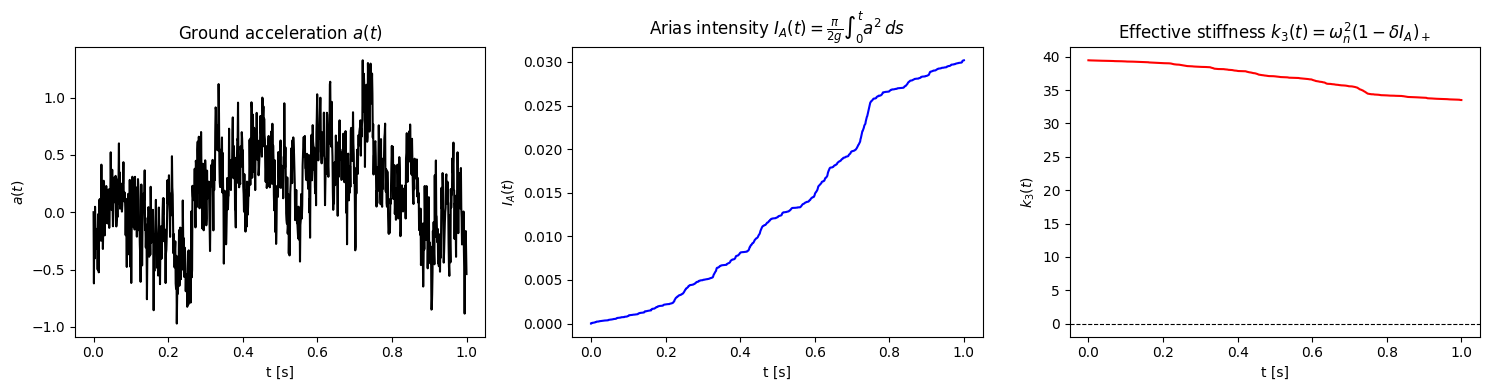

Stiffness remains positive throughout the record.


In [7]:
# Plot ground acceleration, Arias intensity, and effective stiffness
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

t_np      = x.cpu().numpy()
a_np      = a_ground.cpu().numpy()
IA_np     = IA.cpu().numpy()
k3_np     = k3_profile.cpu().numpy()

axes[0].plot(t_np, a_np, 'k-')
axes[0].set_title("Ground acceleration $a(t)$")
axes[0].set_xlabel("t [s]")
axes[0].set_ylabel("$a(t)$")

axes[1].plot(t_np, IA_np, 'b-')
axes[1].set_title(r"Arias intensity $I_A(t) = \frac{\pi}{2g}\int_0^t a^2\,ds$")
axes[1].set_xlabel("t [s]")
axes[1].set_ylabel("$I_A(t)$")

axes[2].plot(t_np, k3_np, 'r-')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_title(r"Effective stiffness $k_3(t) = \omega_n^2(1-\delta I_A)_+$")
axes[2].set_xlabel("t [s]")
axes[2].set_ylabel("$k_3(t)$")

plt.tight_layout()
plt.show()

# Report when/if stiffness hits zero
zero_mask = k3_profile == 0
if zero_mask.any():
    t_zero = x[zero_mask.nonzero(as_tuple=True)[0][0]].item()
    print(f"Stiffness reaches zero at t = {t_zero:.3f} s")
else:
    print("Stiffness remains positive throughout the record.")

## Run Solvers and Train Models

In [8]:
# === Run experiment (Notebook cell) ===
print("Running nonlinear Duffing IVP and signature‑kernel...\n")

# 1) Generate forcing and reference solution
print("solving ivp reference")

x_ref, u_ref = solve_linear_ivp(
    x_grid=x,
    forcing_torch=forcing,
    a=a, b=b,
    ya=ya, ypa=ypa,
    a_fun=a_fun,
    b_fun=b_fun,
    c_fun=c_fun,
)

print("solving plain RBF (no signatures, no extensions)")
urbf, fpred_rbf = solve_rbf_kernel_plain(
        x              = x,
        f              = forcing,
        a_fun=a_fun,
        b_fun=b_fun,
        c_fun=c_fun,
    ua=ya,
    upa=ypa,
    rbfsigma=rbf_sigma,  # reuse the same σ you use for signatures
)


print("solving non branched")
# 2) Non‑branched solver
u_nb, f_pred_nb = \
    solve_signature_kernel_non_branched(
        x              = x,
        f              = forcing,
        a_fun=a_fun,
        b_fun=b_fun,
        c_fun=c_fun,
        ua             = ya,
        upa            = ypa,
        depth          = SIG_DEPTH,
        rbf_sigma      = rbf_sigma,
        kernel_type        = KERNEL_TYPE,
        norm_scheme     = NORM_SCHEME,
        norm_kwargs     = NORM_KWARGS,
    )





# 3) Branched solver
print("Running Branched Solver")
u_sig, snapshots, f_pred_sig, path_ext = \
    solve_signature_kernel_branched(
        x               = x,
        f               = forcing,
        a_fun=a_fun,
        b_fun=b_fun,
        c_fun=c_fun,
        ua              = ya,
        upa             = ypa,
        depth           = SIG_DEPTH,
        adam_iters      = ADAM_ITERS,
        adam_lr         = ADAM_LR,
        ADAM_lambda_model    = ADAM_lambda_model,
        ADAM_lambda_shuffle  = ADAM_lambda_shuffle,
        extensions      = extensions,
        rbf_sigma       = rbf_sigma,
        snapshot_count  = num_snapshots,
        hidden_dims     = HIDDEN_DIMS,
        activation_cls  = ACTIVATION_CLS,
        adam_use_scheduler = ADAM_USE_SCHEDULER,
        adam_sched_factor  = ADAM_SCHED_FACTOR,
        adam_sched_patience= ADAM_SCHED_PATIENCE,
        kernel_type        = KERNEL_TYPE,
        norm_scheme     = NORM_SCHEME,
        norm_kwargs     = NORM_KWARGS,
    )




Running nonlinear Duffing IVP and signature‑kernel...

solving ivp reference
solving plain RBF (no signatures, no extensions)
finding betas (plain RBF kernel)...
time solve betas (RBF): 0.120 s
plain RBF model forcing match loss: 9.982e+00
total time RBF-only: 0.151 s
solving non branched
non-branched model forcing match loss: 5.343e-03
Running Branched Solver
[Adam 0050] loss=2.819e-01, PDE=1.396e-06, shuffle=2.819e+03
[Adam 0100] loss=3.924e-01, PDE=4.744e-06, shuffle=3.924e+03
[Adam 0150] loss=5.554e-01, PDE=2.275e-04, shuffle=5.531e+03
[Adam 0200] loss=1.294e+00, PDE=3.618e-06, shuffle=1.294e+04
[Adam 0250] loss=3.194e+01, PDE=3.978e-03, shuffle=3.190e+05
[Adam 0300] loss=1.024e+01, PDE=2.105e-06, shuffle=1.024e+05
[Adam 0350] loss=4.089e+01, PDE=4.477e-05, shuffle=4.089e+05
[Adam 0400] loss=3.696e+01, PDE=4.485e-04, shuffle=3.695e+05
[Adam 0450] loss=4.231e+01, PDE=1.745e-05, shuffle=4.231e+05
[Adam 0500] loss=2.117e+01, PDE=6.800e-06, shuffle=2.117e+05
[Adam 0550] loss=2.116e+01,

## Compare Model Metrics and Plot Results


[RBF (no signatures)] solution errors vs IVP:
  MSE(u)      = 1.823e-05
  Abs L2(u)   = 4.270e-03
  Rel L2(u)   = 3.435e-02
[RBF (no signatures)] forcing errors vs true f:
  MSE(f)      = 9.982e+00
  Abs L2(f)   = 3.159e+00
  Rel L2(f)   = 7.415e-01

[Non-branched] solution errors vs IVP:
  MSE(u)      = 2.258e-10
  Abs L2(u)   = 1.503e-05
  Rel L2(u)   = 1.209e-04
[Non-branched] forcing errors vs true f:
  MSE(f)      = 5.343e-03
  Abs L2(f)   = 7.310e-02
  Rel L2(f)   = 1.716e-02

[Branched] solution errors vs IVP:
  MSE(u)      = 4.879e-13
  Abs L2(u)   = 6.985e-07
  Rel L2(u)   = 5.620e-06
  Rel improv vs non branched model = 95.35%
[Branched] forcing errors vs true f:
  MSE(f)      = 1.319e-04
  Abs L2(f)   = 1.149e-02
  Rel L2(f)   = 2.696e-03
  Rel improv vs non branched model = 84.29%


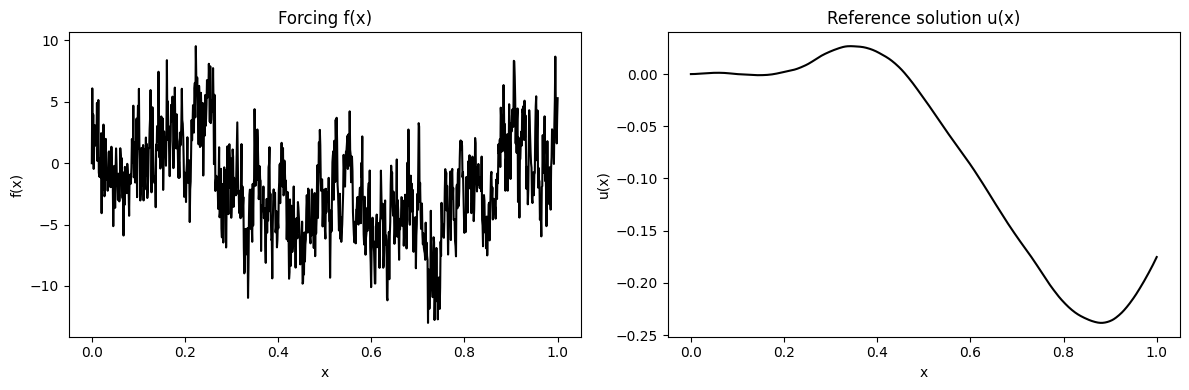

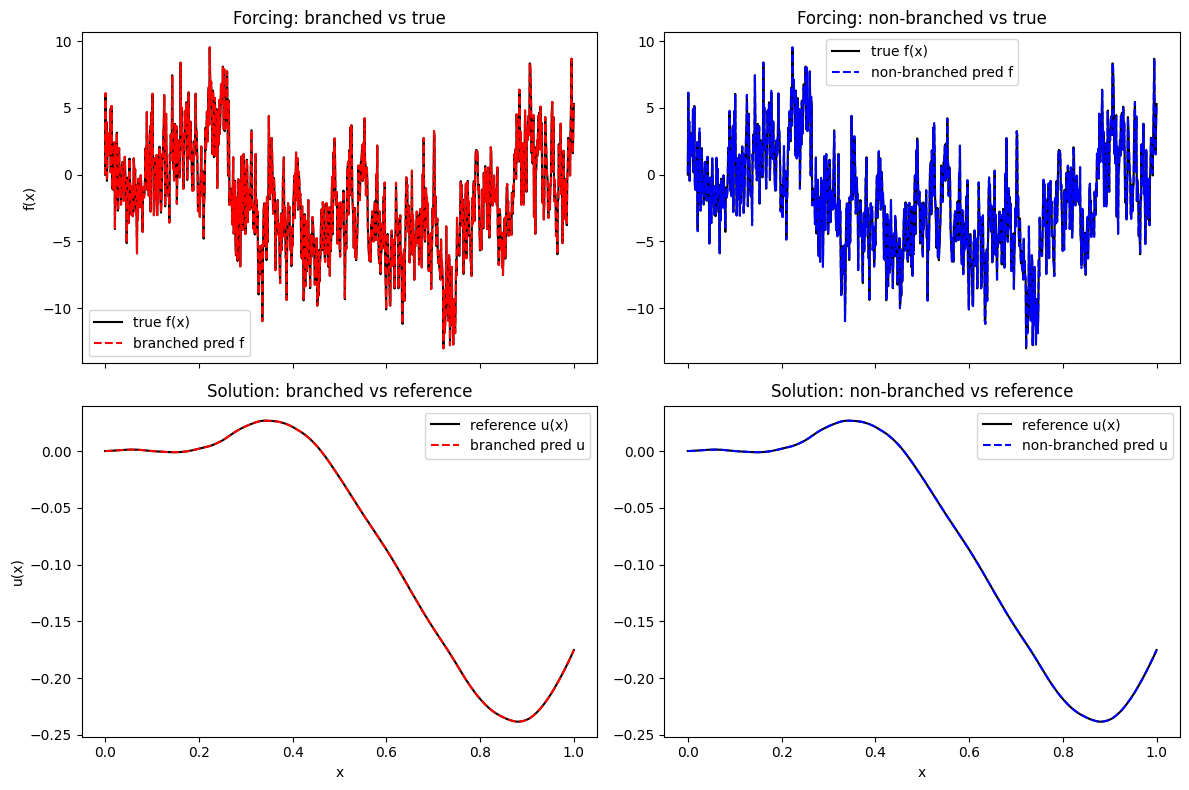

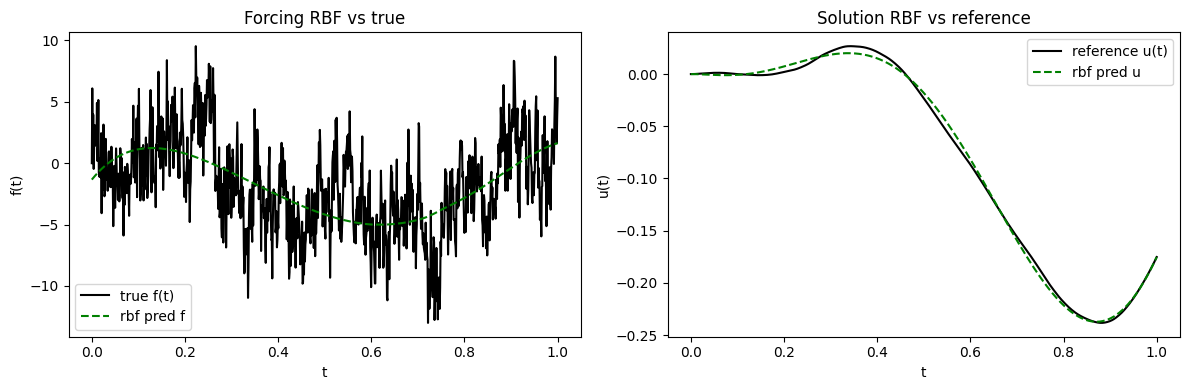

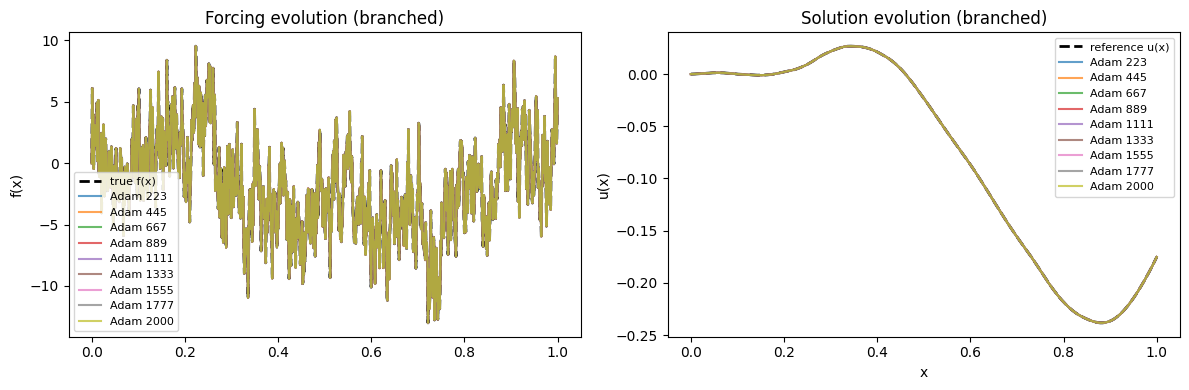

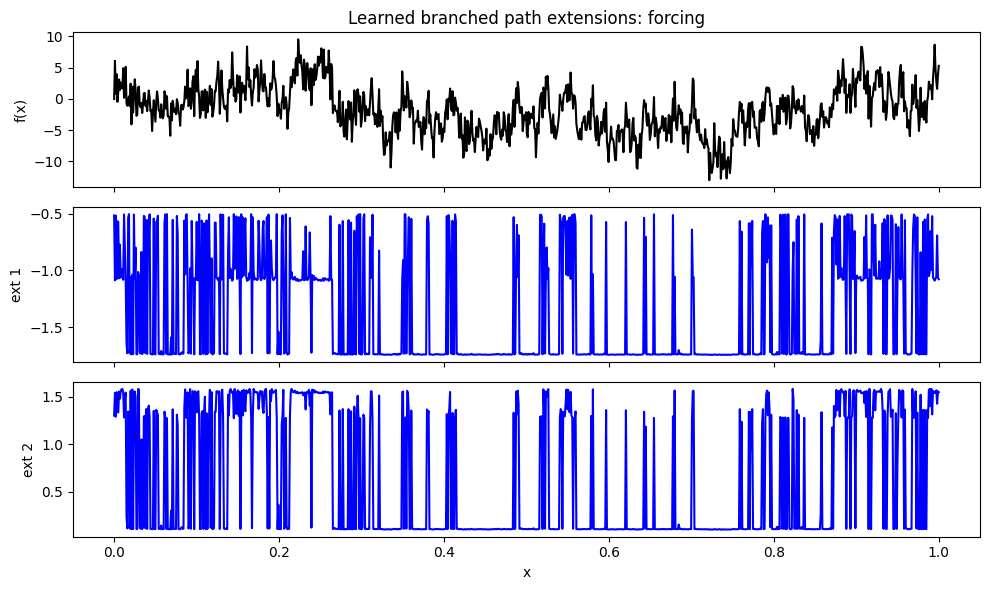

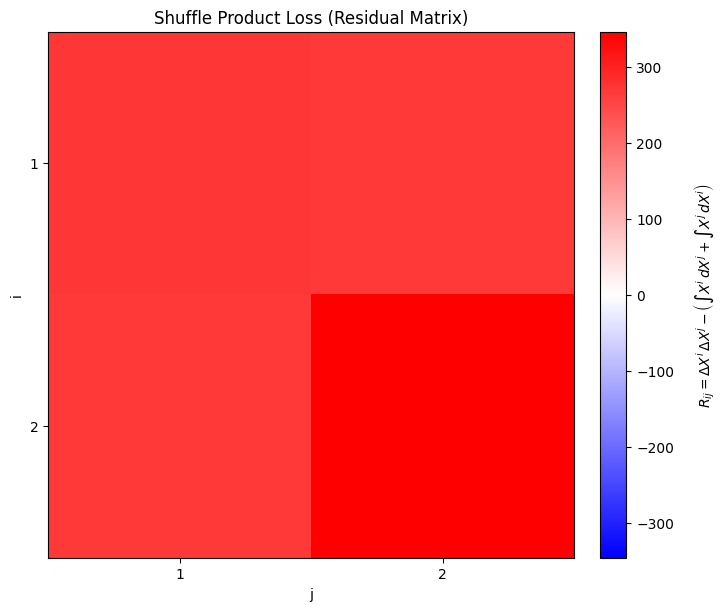


Relative MSE table
Model                   Rel MSE (forcing)   Rel MSE (solution)
--------------------------------------------------------------
RBF                          5.498777e-01         1.179999e-03
Non-branched                 2.943300e-04         1.461334e-08
Branched                     7.268334e-06         3.157956e-11


In [9]:


  # Print errors for all three models
rel_u_rbf, rel_f_rbf = print_errors("RBF (no signatures)", u_ref, urbf, forcing, fpred_rbf)
rel_u_nb,  rel_f_nb  = print_errors("Non-branched", u_ref, u_nb, forcing, f_pred_nb)
rel_u_sig, rel_f_sig = print_errors("Branched", u_ref, u_sig, forcing, f_pred_sig,
                                    ref_rel_u=rel_u_nb, ref_rel_f=rel_f_nb)

# Main comparison plots
plot_reference_forcing_and_solution(x, forcing, u_ref)
plot_final_comparison_2x2(x, forcing, u_ref, u_sig, f_pred_sig, u_nb, f_pred_nb)

# Final plain RBF plot
plot_rbf_final_comparison(x, forcing, u_ref, urbf, fpred_rbf)

# Snapshot evolution for branched model
plot_snapshot_evolution_branched(x, forcing, u_ref, snapshots)

# Learned extensions
with torch.no_grad():
    X_base = torch.stack([x, forcing], dim=1)
    learned_ext = path_ext(X_base)
    X_full_ext = torch.cat([X_base, learned_ext], dim=1)

plot_learned_extensions(x, forcing, X_full_ext, title_prefix="Learned branched path extensions")
plot_shuffle_residual_matrix(x, forcing, path_ext)

# Relative MSE table
mse_u_rbf, relmse_u_rbf = compute_mse_and_relative_mse(u_ref, urbf)
mse_f_rbf, relmse_f_rbf = compute_mse_and_relative_mse(forcing, fpred_rbf)

mse_u_nb, relmse_u_nb = compute_mse_and_relative_mse(u_ref, u_nb)
mse_f_nb, relmse_f_nb = compute_mse_and_relative_mse(forcing, f_pred_nb)

mse_u_sig, relmse_u_sig = compute_mse_and_relative_mse(u_ref, u_sig)
mse_f_sig, relmse_f_sig = compute_mse_and_relative_mse(forcing, f_pred_sig)

print("\nRelative MSE table")
print(f"{'Model':<20} {'Rel MSE (forcing)':>20} {'Rel MSE (solution)':>20}")
print("-" * 62)
print(f"{'RBF':<20} {relmse_f_rbf:>20.6e} {relmse_u_rbf:>20.6e}")
print(f"{'Non-branched':<20} {relmse_f_nb:>20.6e} {relmse_u_nb:>20.6e}")
print(f"{'Branched':<20} {relmse_f_sig:>20.6e} {relmse_u_sig:>20.6e}")

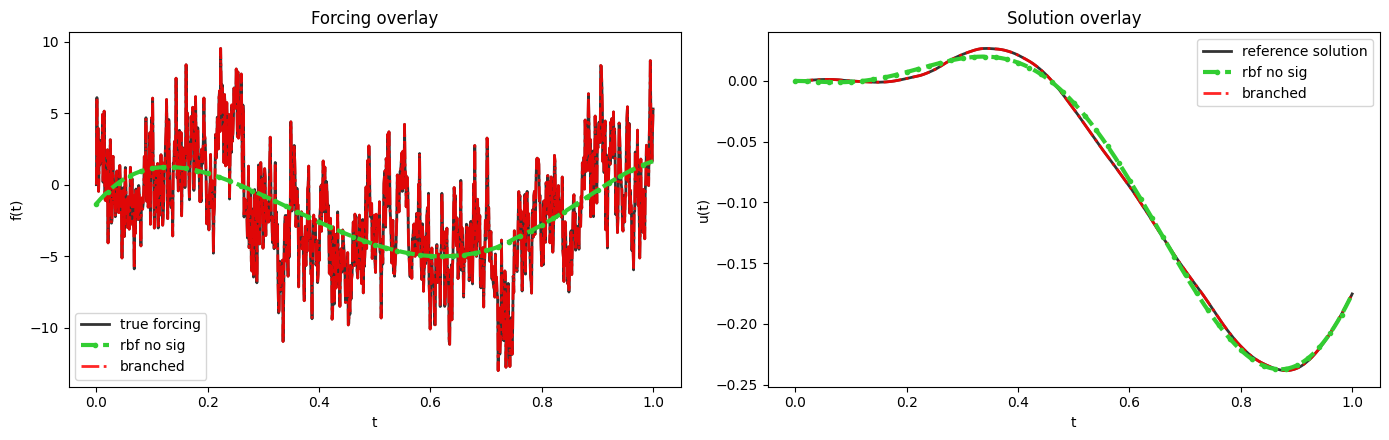

In [10]:

plot_overlay_reference_rbf_branched_1x2(
    x=x,
    f_true=forcing,
    u_ref=u_ref,
    f_rbf=fpred_rbf,
    u_rbf=urbf,
    f_sig=f_pred_sig,
    u_sig=u_sig
)